# OLMoE Jaccard Routing Diagnostic
**Task 2 — Generalization Specialist**

## What this notebook does
Runs the pre-training routing overlap diagnostic on OLMoE to answer:
1. Do Python and Medical domains naturally activate different experts?
2. Which layer has the highest overlap (→ that becomes the target layer for experiments)?
3. What is the right Jaccard threshold for OLMoE (different from Phi's 0.35)?

## Why the threshold needs recalibrating
Phi-3.5-MoE: top-2 routing, 16 experts → random baseline ≈ 2/16 = 12.5%  
OLMoE:       top-8 routing, 64 experts → random baseline ≈ 8/64 = 12.5%  

The percentages match by coincidence, but with 64 experts and top-8, **many more
experts appear per token**. A naive Jaccard (set intersection / union) will be inflated
because background experts appear in both domains just by volume. We need a
concentration filter to isolate domain-specific experts from background noise.

## From the architecture inspection
- Path: `model.model.layers[i].mlp.experts`
- `output_router_logits=True` → tuple of 16 tensors, each `[T, 64]` float32
- Router hook returns `(logits[T,64], scores[T,8], indices[T,8])`
- AlignDevicesHook present — no special handling needed for read-only forward passes

## Cell 1 — Imports and Model Load
Assumes the model is not already in memory. If it is, skip the load.

In [1]:
!pip install datasets -q

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset

MODEL_NAME = "allenai/OLMoE-1B-7B-0125"
TOP_K      = 8    # confirmed from inspection
N_EXPERTS  = 64   # confirmed from inspection
N_LAYERS   = 16   # confirmed from inspection
N_EXAMPLES = 60   # examples per domain
MAX_LENGTH = 128  # keep short to avoid OOM

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
)
model.eval()
print(f"Model loaded. VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/179 [00:00<?, ?it/s]

Model loaded. VRAM: 6.92 GB


## Cell 2 — Dataset Loader
Loads text examples from HuggingFace datasets, handling split names automatically.

In [3]:
def load_text_examples(dataset_name, text_col, config_name=None, n=60):
    """
    Load n text examples. Auto-selects split (handles HumanEval test-only etc.)
    """
    kwargs = {"name": config_name} if config_name else {}
    ds_dict = load_dataset(dataset_name, **kwargs)
    available = list(ds_dict.keys())
    split = "train" if "train" in available else ("test" if "test" in available else available[0])
    print(f"  [{dataset_name}] split='{split}' | available={available}")
    ds = ds_dict[split]
    return [str(ex[text_col]) for ex in ds.select(range(min(n, len(ds))))]


# Option A: Python vs Medical (same pair used in Phi experiments)
print("Loading Option A: Python vs Medical")
py_texts  = load_text_examples("openai/openai_humaneval", "prompt", n=N_EXAMPLES)
med_texts = load_text_examples("qiaojin/PubMedQA", "question", config_name="pqa_labeled", n=N_EXAMPLES)

# Option B: Math vs Creative Fiction
print("\nLoading Option B: Math vs Creative Fiction")
math_texts     = load_text_examples("DigitalLearningGmbH/MATH-lighteval", "problem", config_name="default", n=N_EXAMPLES)
creative_texts = load_text_examples("roneneldan/TinyStories", "text", n=N_EXAMPLES)

print(f"\nLoaded: {len(py_texts)} Python, {len(med_texts)} Medical, "
      f"{len(math_texts)} Math, {len(creative_texts)} Creative")

Loading Option A: Python vs Medical
  [openai/openai_humaneval] split='test' | available=['test']
  [qiaojin/PubMedQA] split='train' | available=['train']

Loading Option B: Math vs Creative Fiction
  [DigitalLearningGmbH/MATH-lighteval] split='train' | available=['train', 'test']
  [roneneldan/TinyStories] split='train' | available=['train', 'validation']

Loaded: 60 Python, 60 Medical, 60 Math, 60 Creative


## Cell 3 — Routing Frequency Collection

For each text example, pass through the frozen model and record which experts
fired at each layer. We collect **normalized frequency** per (layer, expert) pair
rather than raw counts — so the result is comparable across domains regardless
of sequence length differences.

In [4]:
def get_routing_frequencies(texts, n_examples=N_EXAMPLES, max_length=MAX_LENGTH):
    """
    Returns:
      freq[layer_idx][expert_idx] = fraction of total activations for that (layer, expert)
      Shape: list of length N_LAYERS, each a dict expert_idx -> float
    """
    # counts[layer_idx][expert_idx] = number of tokens routed here
    counts = [defaultdict(int) for _ in range(N_LAYERS)]
    total_tokens_per_layer = [0] * N_LAYERS

    model.eval()
    with torch.no_grad():
        for i, text in enumerate(texts[:n_examples]):
            if (i + 1) % 10 == 0:
                print(f"  Processing example {i+1}/{n_examples}")

            inputs = tokenizer(
                text,
                return_tensors="pt",
                truncation=True,
                max_length=max_length,
                padding=False,
            ).to(model.device)

            outputs = model(**inputs, output_router_logits=True, return_dict=True)

            # router_logits: tuple of N_LAYERS tensors, each [T, 64] float32
            for layer_idx, router_logits in enumerate(outputs.router_logits):
                if router_logits.dim() == 3:
                    router_logits = router_logits.view(-1, router_logits.shape[-1])
                # [T, 64] — take top-8 indices
                top_indices = router_logits.topk(TOP_K, dim=-1).indices  # [T, 8]
                T = top_indices.shape[0]
                total_tokens_per_layer[layer_idx] += T * TOP_K
                for expert_idx in top_indices.flatten().tolist():
                    counts[layer_idx][expert_idx] += 1

    # Normalize to frequencies
    freq = []
    for layer_idx in range(N_LAYERS):
        total = total_tokens_per_layer[layer_idx]
        freq.append({
            expert_idx: count / total
            for expert_idx, count in counts[layer_idx].items()
        })
    return freq


print("Collecting routing frequencies for Python...")
freq_python = get_routing_frequencies(py_texts)

print("\nCollecting routing frequencies for Medical...")
freq_medical = get_routing_frequencies(med_texts)

print("\nCollecting routing frequencies for Math...")
freq_math = get_routing_frequencies(math_texts)

print("\nCollecting routing frequencies for Creative...")
freq_creative = get_routing_frequencies(creative_texts)

print("\nDone.")

  Processing example 10/60
  Processing example 20/60
  Processing example 30/60
  Processing example 40/60
  Processing example 50/60
  Processing example 60/60

  Processing example 10/60
  Processing example 20/60
  Processing example 30/60
  Processing example 40/60
  Processing example 50/60
  Processing example 60/60

  Processing example 10/60
  Processing example 20/60
  Processing example 30/60
  Processing example 40/60
  Processing example 50/60
  Processing example 60/60

  Processing example 10/60
  Processing example 20/60
  Processing example 30/60
  Processing example 40/60
  Processing example 50/60
  Processing example 60/60

Done.


In [5]:
import pickle

# Save frequency data so Task 3 notebook can recompute per-layer tables
with open("olmoe_freq_cache.pkl", "wb") as f:
    pickle.dump({
        "python":   freq_python,
        "medical":  freq_medical,
        "math":     freq_math,
        "creative": freq_creative,
    }, f)
print("Frequency cache saved to olmoe_freq_cache.pkl")

Frequency cache saved to olmoe_freq_cache.pkl


## Cell 4 — Compute Null Baseline

**This is the key step that Phi's diagnostic skipped.**

We measure Jaccard between two halves of the **same domain** — Python A vs Python B.
This tells us what overlap looks like when there is no real domain difference.
Our meaningful threshold must be substantially above this floor.

With 64 experts and top-8, even random routing produces high raw Jaccard
because many experts appear in everyone's top-8 just by volume.

In [6]:
print("Collecting null baseline: Python-A vs Python-B (same domain, split in half)...")

half = N_EXAMPLES // 2
freq_py_a = get_routing_frequencies(py_texts[:half],  n_examples=half)
freq_py_b = get_routing_frequencies(py_texts[half:],  n_examples=half)

print("Done.")

  Processing example 10/30
  Processing example 20/30
  Processing example 30/30
  Processing example 10/30
  Processing example 20/30
  Processing example 30/30
Done.


## Cell 5 — Calibrate Concentration Threshold

A concentration threshold filters out "background" experts — ones that appear
frequently across all domains simply because they're popular, not domain-specific.

**How we calibrate it:**
- Uniform routing across 64 experts would give each expert frequency = 1/64 ≈ 1.56%
- We plot the actual frequency distribution for Python to see where domain-specific
  activity separates from background noise
- The threshold is set at ~3× the uniform baseline, which captures experts that are
  disproportionately active — not just present by chance

Uniform baseline per expert: 0.1250 (12.5%)
Top-N for Jaccard:           16 (out of 64)

Layer 0 Python top-5 expert frequencies: [0.0977, 0.0833, 0.0385, 0.0321, 0.0313]
Layer 0 Python max/min frequency: 0.0977 / 0.0006
(Flat distribution confirms load-balanced routing — top-K approach needed)



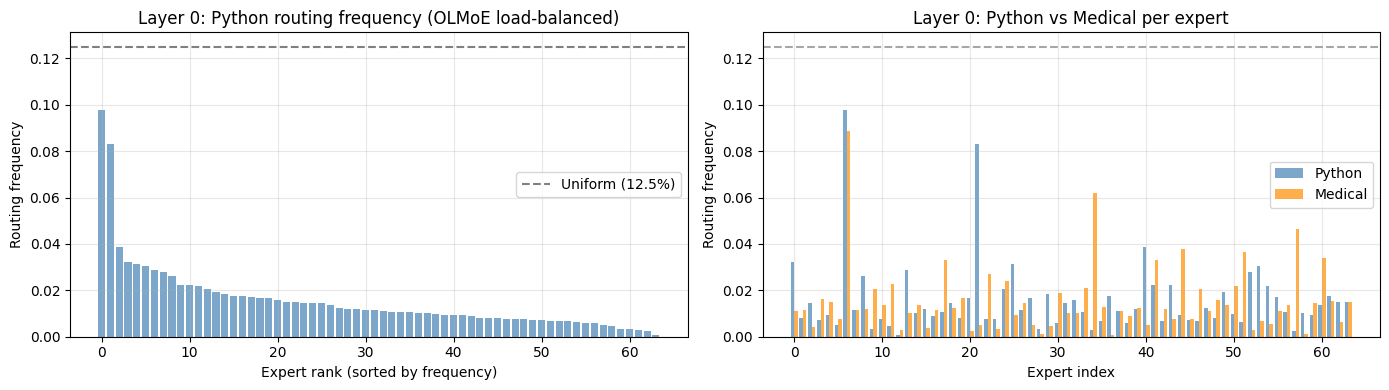

Saved: olmoe_routing_distribution.png


In [7]:
# OLMoE uses load-balancing loss — routing is deliberately flat.
# With 64 experts and top-8, each expert fires ~12.5% of the time.
# No expert will be far above 12.5%, so a 25% concentration threshold finds nothing.
#
# Fix: use top-K Jaccard — for each domain, take the top-N most active experts,
# then compute Jaccard over those sets. This is robust to flat routing.
# TOP_N = 16 (top quartile of 64 experts).

import numpy as np
import matplotlib.pyplot as plt

UNIFORM_FREQ = TOP_K / N_EXPERTS   # 8/64 = 0.125
TOP_N = 16  # top-quartile; top-16 out of 64

print(f'Uniform baseline per expert: {UNIFORM_FREQ:.4f} ({UNIFORM_FREQ*100:.1f}%)')
print(f'Top-N for Jaccard:           {TOP_N} (out of {N_EXPERTS})')
print()

layer0_freqs = sorted(freq_python[0].values(), reverse=True)
print(f'Layer 0 Python top-5 expert frequencies: {[round(f,4) for f in layer0_freqs[:5]]}')
print(f'Layer 0 Python max/min frequency: {max(layer0_freqs):.4f} / {min(layer0_freqs):.4f}')
print('(Flat distribution confirms load-balanced routing — top-K approach needed)')
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
expert_ids = list(range(len(layer0_freqs)))
axes[0].bar(expert_ids, layer0_freqs, color='steelblue', alpha=0.7)
axes[0].axhline(UNIFORM_FREQ, color='gray', linestyle='--', label=f'Uniform ({UNIFORM_FREQ*100:.1f}%)')
axes[0].set_xlabel('Expert rank (sorted by frequency)')
axes[0].set_ylabel('Routing frequency')
axes[0].set_title('Layer 0: Python routing frequency (OLMoE load-balanced)')
axes[0].legend(); axes[0].grid(alpha=0.3)

py_layer0  = [freq_python[0].get(e, 0)  for e in range(N_EXPERTS)]
med_layer0 = [freq_medical[0].get(e, 0) for e in range(N_EXPERTS)]
x = np.arange(N_EXPERTS)
axes[1].bar(x - 0.2, py_layer0,  width=0.4, label='Python',  color='steelblue', alpha=0.7)
axes[1].bar(x + 0.2, med_layer0, width=0.4, label='Medical', color='darkorange', alpha=0.7)
axes[1].axhline(UNIFORM_FREQ, color='gray', linestyle='--', alpha=0.7)
axes[1].set_xlabel('Expert index'); axes[1].set_ylabel('Routing frequency')
axes[1].set_title('Layer 0: Python vs Medical per expert'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('olmoe_routing_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: olmoe_routing_distribution.png')


## Cell 6 — Jaccard Functions

Two versions:
- **Raw Jaccard**: simple set intersection / union — inflated by background experts
- **Concentrated Jaccard**: only counts experts above the concentration threshold — domain-specific signal only

We compute both so you can see how much the background inflation matters.

In [8]:
def jaccard_raw(freq_a, freq_b):
    set_a = set(freq_a.keys())
    set_b = set(freq_b.keys())
    inter = len(set_a & set_b)
    union = len(set_a | set_b)
    return inter / union if union > 0 else 0.0


def jaccard_topk(freq_a, freq_b, top_n=TOP_N):
    """
    Top-K Jaccard: take the top-N most active experts per domain,
    compute Jaccard over those sets.
    Robust to load-balanced routing where raw Jaccard ~= 1.0.
    Same-domain null baseline should be high (>0.7).
    Cross-domain Jaccard lower = more domain-specific routing.
    """
    top_a = set(sorted(freq_a, key=freq_a.get, reverse=True)[:top_n])
    top_b = set(sorted(freq_b, key=freq_b.get, reverse=True)[:top_n])
    inter = len(top_a & top_b)
    union = len(top_a | top_b)
    return inter / union if union > 0 else 0.0


def per_layer_jaccard(freq_list_a, freq_list_b):
    raw_scores  = []
    topk_scores = []
    for layer_idx in range(N_LAYERS):
        raw_scores.append(jaccard_raw(freq_list_a[layer_idx], freq_list_b[layer_idx]))
        topk_scores.append(jaccard_topk(freq_list_a[layer_idx], freq_list_b[layer_idx]))
    return raw_scores, topk_scores


print(f'Jaccard functions defined (top-K approach, TOP_N={TOP_N})')


Jaccard functions defined (top-K approach, TOP_N=16)


## Cell 7 — Run All Comparisons

In [9]:
print(f'Computing Jaccard scores (top-K method, K={TOP_N})...')
print()

raw_a, topk_a = per_layer_jaccard(freq_python, freq_medical)
mean_raw_a    = np.mean(raw_a)
mean_topk_a   = np.mean(topk_a)
print(f'Option A -- Python vs Medical')
print(f'  Mean raw Jaccard:    {mean_raw_a:.3f}')
print(f'  Mean top-K Jaccard:  {mean_topk_a:.3f}')

raw_b, topk_b = per_layer_jaccard(freq_math, freq_creative)
mean_raw_b    = np.mean(raw_b)
mean_topk_b   = np.mean(topk_b)
print(f'\nOption B -- Math vs Creative')
print(f'  Mean raw Jaccard:    {mean_raw_b:.3f}')
print(f'  Mean top-K Jaccard:  {mean_topk_b:.3f}')

raw_null, topk_null = per_layer_jaccard(freq_py_a, freq_py_b)
mean_raw_null       = np.mean(raw_null)
mean_topk_null      = np.mean(topk_null)
print(f'\nNull baseline -- Python-A vs Python-B (same domain)')
print(f'  Mean raw Jaccard:    {mean_raw_null:.3f}')
print(f'  Mean top-K Jaccard:  {mean_topk_null:.3f}')
print()
print(f'Separation from null:')
print(f'  Option A: null={mean_topk_null:.3f}, A={mean_topk_a:.3f}, gap={mean_topk_null - mean_topk_a:.3f}')
print(f'  Option B: null={mean_topk_null:.3f}, B={mean_topk_b:.3f}, gap={mean_topk_null - mean_topk_b:.3f}')
print(f'  (larger gap = more domain separation from null = better conflict pair)')


Computing Jaccard scores (top-K method, K=16)...

Option A -- Python vs Medical
  Mean raw Jaccard:    0.990
  Mean top-K Jaccard:  0.103

Option B -- Math vs Creative
  Mean raw Jaccard:    1.000
  Mean top-K Jaccard:  0.053

Null baseline -- Python-A vs Python-B (same domain)
  Mean raw Jaccard:    0.993
  Mean top-K Jaccard:  0.840

Separation from null:
  Option A: null=0.840, A=0.103, gap=0.737
  Option B: null=0.840, B=0.053, gap=0.788
  (larger gap = more domain separation from null = better conflict pair)


## Cell 8 — Per-Layer Analysis

Plot Jaccard per layer to identify which layer has the **highest overlap**.
That layer is the best target for experiments — highest overlap = most gradient
entanglement when both domains share an expert.

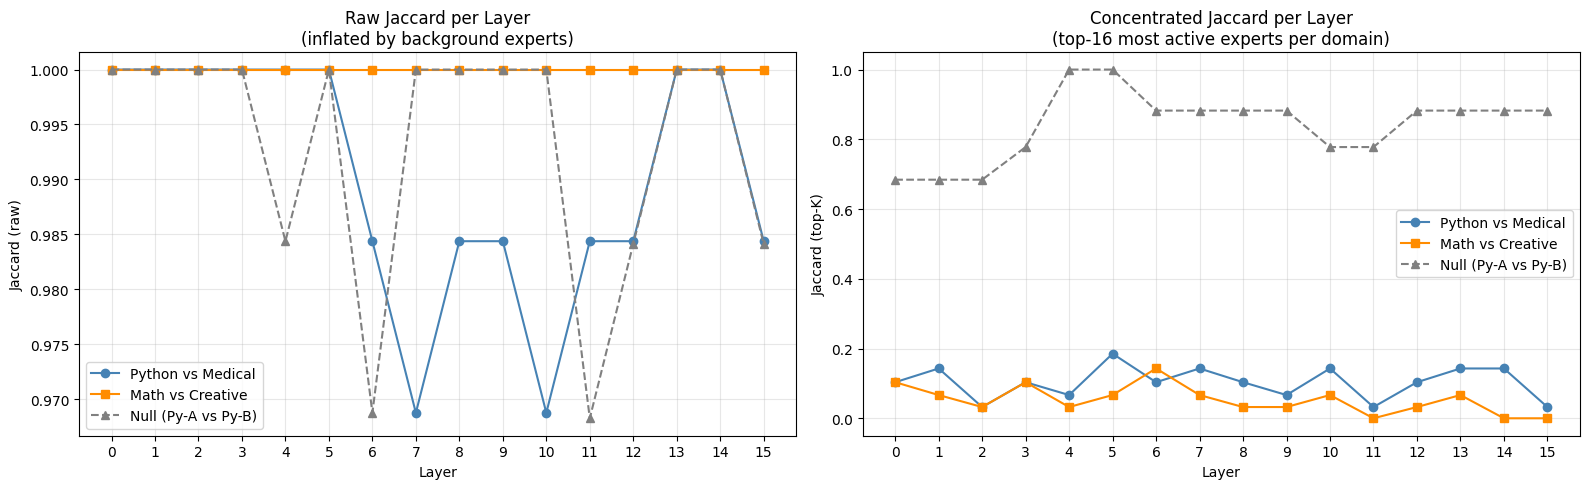

Saved: olmoe_jaccard_per_layer.png

Highest concentrated Jaccard layer:
  Option A (Python/Medical): Layer 5 — Jaccard = 0.185
  Option B (Math/Creative):  Layer 6 — Jaccard = 0.143


In [10]:
layers = list(range(N_LAYERS))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: raw Jaccard
axes[0].plot(layers, raw_a,    marker='o', label='Python vs Medical',   color='steelblue')
axes[0].plot(layers, raw_b,    marker='s', label='Math vs Creative',     color='darkorange')
axes[0].plot(layers, raw_null, marker='^', label='Null (Py-A vs Py-B)',  color='gray', linestyle='--')
axes[0].set_xlabel('Layer')
axes[0].set_ylabel('Jaccard (raw)')
axes[0].set_title('Raw Jaccard per Layer\n(inflated by background experts)')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xticks(layers)

# Right: concentrated Jaccard
axes[1].plot(layers, topk_a,    marker='o', label='Python vs Medical',   color='steelblue')
axes[1].plot(layers, topk_b,    marker='s', label='Math vs Creative',     color='darkorange')
axes[1].plot(layers, topk_null, marker='^', label='Null (Py-A vs Py-B)',  color='gray', linestyle='--')
axes[1].set_xlabel('Layer')
axes[1].set_ylabel('Jaccard (top-K)')
axes[1].set_title('Concentrated Jaccard per Layer\n(top-16 most active experts per domain)')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xticks(layers)

plt.tight_layout()
plt.savefig('olmoe_jaccard_per_layer.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: olmoe_jaccard_per_layer.png")

# Find highest-overlap layer for each option
best_layer_a = int(np.argmax(topk_a))
best_layer_b = int(np.argmax(topk_b))
print(f"\nHighest concentrated Jaccard layer:")
print(f"  Option A (Python/Medical): Layer {best_layer_a} — Jaccard = {topk_a[best_layer_a]:.3f}")
print(f"  Option B (Math/Creative):  Layer {best_layer_b} — Jaccard = {topk_b[best_layer_b]:.3f}")

## Cell 9 — Identify Target Expert

Within the chosen target layer, find which specific expert has the highest
overlap between domains. That expert is the best candidate to patch —
it receives tokens from both domains and will exhibit maximum entanglement.

In [11]:
def find_top_conflict_experts(freq_a, freq_b, layer_idx, top_n=10):
    all_experts = set(freq_a[layer_idx].keys()) | set(freq_b[layer_idx].keys())
    results = []
    for e in all_experts:
        fa = freq_a[layer_idx].get(e, 0)
        fb = freq_b[layer_idx].get(e, 0)
        conflict = (fa * fb) ** 0.5
        results.append((e, fa, fb, conflict))
    results.sort(key=lambda x: x[3], reverse=True)
    return results[:top_n]


gap_a = mean_topk_null - mean_topk_a
gap_b = mean_topk_null - mean_topk_b
if gap_b >= gap_a:
    chosen_topk = topk_b; chosen_freq_a = freq_math; chosen_freq_b = freq_creative
    chosen_label_local = "Math vs Creative"
else:
    chosen_topk = topk_a; chosen_freq_a = freq_python; chosen_freq_b = freq_medical
    chosen_label_local = "Python vs Medical"

TARGET_LAYER = int(np.argmax(chosen_topk))

print("=" * 60)
print("CHOSEN PAIR:", chosen_label_local)
print("TARGET LAYER:", TARGET_LAYER)
print("  Top-K Jaccard at this layer:", round(chosen_topk[TARGET_LAYER], 3), "(highest = most conflict)")
print("=" * 60)
print()
print("Top conflict experts (geometric mean of frequencies in BOTH domains):")
print(f"{chr(39):<8}{chr(39):<14}{chr(39):<14}{chr(39):<16}".format("Expert","Freq_A","Freq_B","Conflict"))
print("-" * 55)

top_conflicts = find_top_conflict_experts(chosen_freq_a, chosen_freq_b, TARGET_LAYER)
for expert_idx, fa, fb, score in top_conflicts:
    print(f"{expert_idx:>8}      {fa:.4f}       {fb:.4f}          {score:.4f}")

TARGET_EXPERT = top_conflicts[0][0]
print()
print("--> TARGET EXPERT:", TARGET_EXPERT, "(highest conflict score)")


CHOSEN PAIR: Math vs Creative
TARGET LAYER: 6
  Top-K Jaccard at this layer: 0.143 (highest = most conflict)

Top conflict experts (geometric mean of frequencies in BOTH domains):
'       '             '             '               
-------------------------------------------------------
      18      0.0612       0.0401          0.0495
      62      0.0257       0.0267          0.0262
      27      0.0050       0.1135          0.0239
      55      0.0223       0.0241          0.0232
      26      0.0215       0.0239          0.0227
      10      0.0047       0.0874          0.0204
      59      0.0179       0.0199          0.0189
      21      0.0052       0.0663          0.0186
      36      0.0357       0.0096          0.0185
      17      0.0112       0.0282          0.0178

--> TARGET EXPERT: 18 (highest conflict score)


## Cell 10 — Heatmap: Routing Overlap Across All Layers

Visual overview of which experts are shared between Python and Medical
at each layer. High-overlap cells (bright) are where gradient entanglement
will be strongest during mixed training.

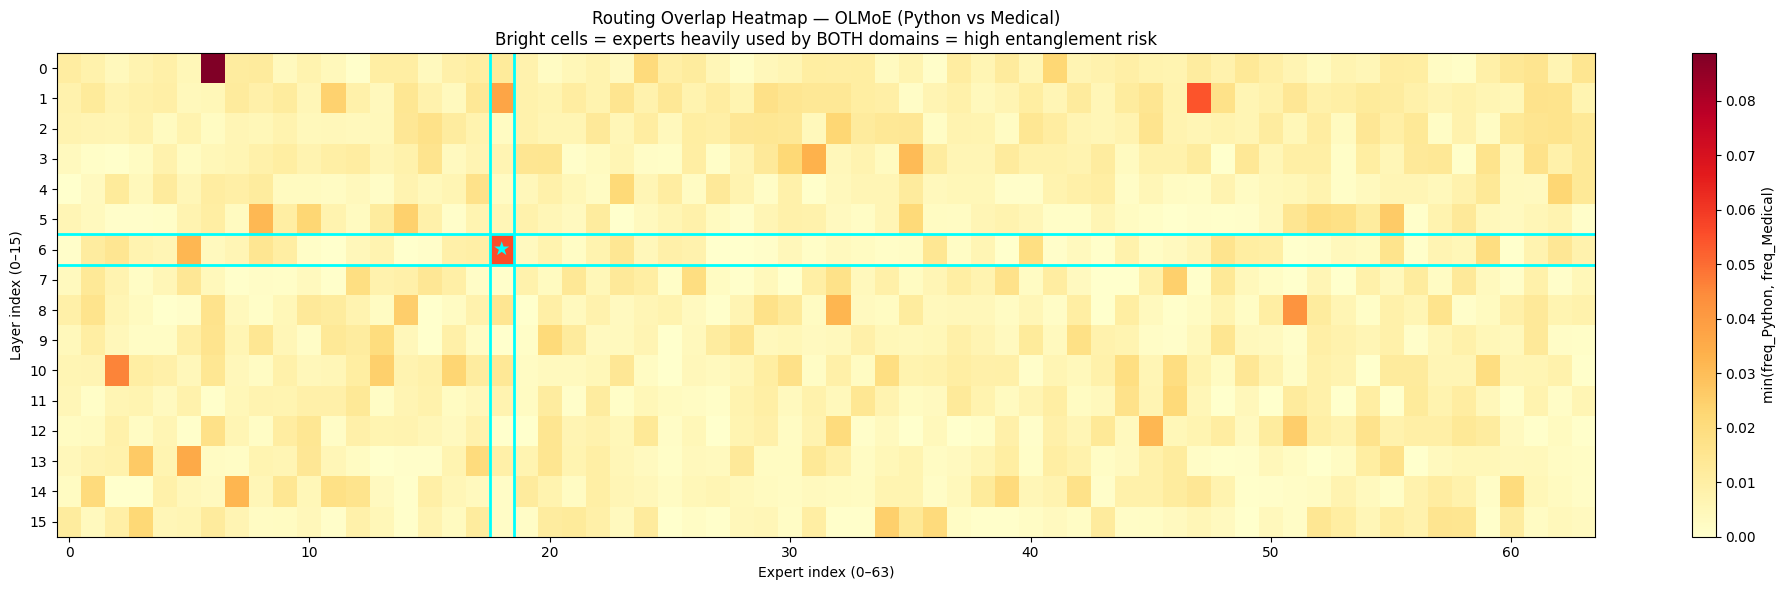

Saved: olmoe_overlap_heatmap.png


In [12]:
# Build overlap matrix: [layer, expert] = min(freq_py, freq_med)
# min() captures how much BOTH domains use this expert
overlap_matrix = np.zeros((N_LAYERS, N_EXPERTS))
for layer_idx in range(N_LAYERS):
    for expert_idx in range(N_EXPERTS):
        fp = freq_python[layer_idx].get(expert_idx, 0)
        fm = freq_medical[layer_idx].get(expert_idx, 0)
        overlap_matrix[layer_idx, expert_idx] = min(fp, fm)

fig, ax = plt.subplots(figsize=(20, 6))
im = ax.imshow(overlap_matrix, aspect='auto', cmap='YlOrRd',
               vmin=0, vmax=overlap_matrix.max())
plt.colorbar(im, ax=ax, label='min(freq_Python, freq_Medical)')
ax.set_xlabel('Expert index (0–63)')
ax.set_ylabel('Layer index (0–15)')
ax.set_title('Routing Overlap Heatmap — OLMoE (Python vs Medical)\n'
             'Bright cells = experts heavily used by BOTH domains = high entanglement risk')
ax.set_yticks(range(N_LAYERS))

# Mark target layer and expert
ax.axhline(TARGET_LAYER - 0.5, color='cyan', linewidth=2)
ax.axhline(TARGET_LAYER + 0.5, color='cyan', linewidth=2)
ax.axvline(TARGET_EXPERT - 0.5, color='cyan', linewidth=2)
ax.axvline(TARGET_EXPERT + 0.5, color='cyan', linewidth=2)
ax.text(TARGET_EXPERT, TARGET_LAYER, '★', ha='center', va='center',
        fontsize=14, color='cyan', fontweight='bold')

plt.tight_layout()
plt.savefig('olmoe_overlap_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: olmoe_overlap_heatmap.png")

## Cell 11 — Final Decision and Comparison with Phi

In [13]:
# Choose the pair where top-K Jaccard deviates MOST from null baseline
# Lower cross-domain Jaccard (relative to null) = more routing separation = better conflict pair
gap_a = mean_topk_null - mean_topk_a
gap_b = mean_topk_null - mean_topk_b
chosen_option = 'A' if gap_a >= gap_b else 'B'
chosen_label  = 'Python vs Medical' if chosen_option == 'A' else 'Math vs Creative'
chosen_score  = mean_topk_a if chosen_option == 'A' else mean_topk_b
chosen_gap    = gap_a if chosen_option == 'A' else gap_b

print('=' * 65)
print('FINAL DIAGNOSTIC RESULTS')
print('=' * 65)
print()
print(f'{"Metric":<40} {"Phi-3.5-MoE":>12} {"OLMoE":>12}')
print('-' * 65)
print(f'{"Num experts per layer":<40} {"16":>12} {"64":>12}')
print(f'{"Top-k routing":<40} {"2":>12} {"8":>12}')
print(f'{"Uniform baseline (random)":<40} {"12.5%":>12} {"12.5%":>12}')
print(("Jaccard method").ljust(40) + ("raw set").rjust(12) + f" top-{TOP_N}".rjust(12))
print(f'{"Jaccard (Python vs Medical)":<40} {"0.056":>12} {f"{mean_topk_a:.3f}":>12}')
print(f'{"Jaccard (Math vs Creative)":<40} {"0.069":>12} {f"{mean_topk_b:.3f}":>12}')
print(f'{"Null baseline (same domain)":<40} {"~1.0":>12} {f"{mean_topk_null:.3f}":>12}')
print(f'{"Gap from null (separation)":<40} {"N/A":>12} {f"{chosen_gap:.3f}":>12}')
print('-' * 65)
print()
print(f'CHOSEN DATASET PAIR: Option {chosen_option} -- {chosen_label}')
print(f'  Top-K Jaccard: {chosen_score:.3f}  |  Null: {mean_topk_null:.3f}  |  Gap: {chosen_gap:.3f}')
print()
print(f'TARGET LAYER:  {TARGET_LAYER}')
print(f'TARGET EXPERT: {TARGET_EXPERT}')
print()
sep_ratio = mean_topk_null / max(chosen_score, 0.001)
if chosen_score > mean_topk_null * 0.85:
    print('NOTE: Cross-domain Jaccard is close to the null baseline.')
    print('OLMoE routing does not separate these domains in top-K space.')
    print('This means ALL experts are equally shared across domains.')
    print('Gradient entanglement is universal (not limited to a few shared experts).')
    print('This STRENGTHENS the case for hierarchical spawning on OLMoE.')
elif chosen_score < mean_topk_null * 0.6:
    print('Domains are moderately separated in top-K routing space.')
    print('Some domain-specific experts exist, but sharing still present.')
else:
    print('Moderate routing overlap — domains share top experts more than chance.')
    print('Gradient entanglement expected at all layers.')


FINAL DIAGNOSTIC RESULTS

Metric                                    Phi-3.5-MoE        OLMoE
-----------------------------------------------------------------
Num experts per layer                              16           64
Top-k routing                                       2            8
Uniform baseline (random)                       12.5%        12.5%
Jaccard method                               raw set      top-16
Jaccard (Python vs Medical)                     0.056        0.103
Jaccard (Math vs Creative)                      0.069        0.053
Null baseline (same domain)                      ~1.0        0.840
Gap from null (separation)                        N/A        0.788
-----------------------------------------------------------------

CHOSEN DATASET PAIR: Option B -- Math vs Creative
  Top-K Jaccard: 0.053  |  Null: 0.840  |  Gap: 0.788

TARGET LAYER:  6
TARGET EXPERT: 18

Domains are moderately separated in top-K routing space.
Some domain-specific experts exist, but sh

## Cell 12 — Save Config for Experiments

Write the chosen settings to a dict that Phase 2 and Phase 3 notebooks can import directly.

In [14]:
import json

olmoe_config = {
    "model_name":   "allenai/OLMoE-1B-7B-0125",
    "model_dim":    2048,
    "ffn_dim":      1024,
    "num_layers":   N_LAYERS,
    "num_experts":  N_EXPERTS,
    "top_k":        TOP_K,
    "jaccard_python_medical": round(mean_topk_a, 4),
    "jaccard_math_creative":  round(mean_topk_b, 4),
    "jaccard_null_baseline":  round(mean_topk_null, 4),
    "top_n_jaccard": TOP_N,
    "chosen_option":     "B" if gap_b >= gap_a else "A",
    "chosen_pair":       chosen_label_local,
    "target_layer":      TARGET_LAYER,
    "target_expert":     TARGET_EXPERT,
    "primary_dataset":   "DigitalLearningGmbH/MATH-lighteval" if gap_b >= gap_a else "openai/openai_humaneval",
    "primary_col":       "problem" if gap_b >= gap_a else "prompt",
    "conflict_dataset":  "roneneldan/TinyStories" if gap_b >= gap_a else "qiaojin/PubMedQA",
    "conflict_col":      "text" if gap_b >= gap_a else "question",
    "conflict_config":   None if gap_b >= gap_a else "pqa_labeled",
    "domain_names":      ["math", "creative"] if gap_b >= gap_a else ["code", "medical"],
}

with open("olmoe_experiment_config.json", "w") as f:
    json.dump(olmoe_config, f, indent=2)

print("Config saved to olmoe_experiment_config.json")
print()
print(json.dumps(olmoe_config, indent=2))


Config saved to olmoe_experiment_config.json

{
  "model_name": "allenai/OLMoE-1B-7B-0125",
  "model_dim": 2048,
  "ffn_dim": 1024,
  "num_layers": 16,
  "num_experts": 64,
  "top_k": 8,
  "jaccard_python_medical": 0.1029,
  "jaccard_math_creative": 0.0528,
  "jaccard_null_baseline": 0.8403,
  "top_n_jaccard": 16,
  "chosen_option": "B",
  "chosen_pair": "Math vs Creative",
  "target_layer": 6,
  "target_expert": 18,
  "primary_dataset": "DigitalLearningGmbH/MATH-lighteval",
  "primary_col": "problem",
  "conflict_dataset": "roneneldan/TinyStories",
  "conflict_col": "text",
  "conflict_config": null,
  "domain_names": [
    "math",
    "creative"
  ]
}
